# Introduction to Notebooks in XNAT

This notebook provides an introduction to working with Jupyter Notebooks within the XNAT environment. It covers essential tools, data exploration, and programmatic access to XNAT resources.

---
## 1. Basic Commands & Tools

This section covers the fundamental commands and tools you'll use when working in a Jupyter Notebook environment.

### 1.1 Shell/Terminal Fundamentals

You can run shell commands directly in Jupyter notebooks by prefixing them with `!`.

However, if you are more comfortable with terminal commands, you can open a terminal in XNAT by navigating to the landing page and selecting the "Terminal" option.

Remeber, for most commands, using the argument `--help` will show you the syntax for how the command is used and the arguments that the command can take!


#### Navigation Commands

**`pwd`** - Print Working Directory: Shows your current location in the file system.

In [1]:
!pwd

/workspace/dnaxuser-wustl_mthorpe_adapt/Notebooks/Introduction_Notebook


**`ls`** - List: Shows files and directories in the current location.

In [2]:
# Basic listing
!ls

README.md  intro_xnat_nb.ipynb


In [3]:
# Detailed listing with hidden files
!ls -la  # "l" for long format, "a" for all files including hidden ones

total 60
drwxrwxr-x. 3 dnaxuser-wustl_mthorpe_adapt dnaxuser-wustl_mthorpe_adapt  6144 Jan 13 17:31 .
drwxrwxr-x. 8 dnaxuser-wustl_mthorpe_adapt dnaxuser-wustl_mthorpe_adapt  6144 Jan 13 17:13 ..
drwxrwxr-x. 2 dnaxuser-wustl_mthorpe_adapt dnaxuser-wustl_mthorpe_adapt  6144 Jan 13 17:13 .ipynb_checkpoints
-rw-rw-r--. 1 dnaxuser-wustl_mthorpe_adapt dnaxuser-wustl_mthorpe_adapt  2756 Jan 13 17:13 README.md
-rw-rw-r--. 1 dnaxuser-wustl_mthorpe_adapt dnaxuser-wustl_mthorpe_adapt 41748 Jan 13 17:31 intro_xnat_nb.ipynb


**`cd`** - Change Directory: Navigate to a different directory. Note that `!cd` won't persist between cells, so we use the `%cd` magic command instead.

In [13]:
# Change to home directory
%cd ~

/home/dnaxuser-wustl_mthorpe_adapt


In [14]:
# Go back to previous directory
%cd -

/workspace/dnaxuser-wustl_mthorpe_adapt/Notebooks/Introduction_Notebook


#### File Operations

**`mkdir`** - Make Directory: Create a new directory.

In [15]:
# Create a test directory
!mkdir -p test_directory  # "-p" is for "parents", a flag to avoid error if directory already exists
!ls

README.md  intro_xnat_nb.ipynb	test_directory


**`cp`** - Copy: Copy files or directories.

In [16]:
# Create a sample file and copy it
!echo "Hello XNAT" > sample.txt  # echo can be used to pass small text chunks into files

!cp sample.txt test_directory/  # Copying our file into the test_directory we created

!ls test_directory/  # Checking that our file was copied

sample.txt


**`mv`** - Move: Move files, but can also rename files!

In [17]:
# Rename the file
!mv test_directory/sample.txt test_directory/renamed.txt  # Renaming our file that we copied


!ls test_directory/  # Checking that the file was renamed!

renamed.txt


**`rm`** - Remove: Delete files or directories. **Use with caution!**

In [18]:
# Clean up our test files
!rm sample.txt  # Will remove our original file

# Will remove our test_directory & "-r" recursively deletes all dirs and files in the directory
!rm -r test_directory

#### Viewing File Contents

**`cat`** - Concatenate: Display entire file contents.

In [19]:
# Create a sample file to view
!echo -e "Line 1\nLine 2\nLine 3\nLine 4\nLine 5" > viewtest.txt


!cat viewtest.txt  # Cat let's us quickily inspect what is in a file!

Line 1
Line 2
Line 3
Line 4
Line 5


**`head`** - View the first few lines of a file.

In [20]:
# Show first 3 lines
!head -n 3 viewtest.txt

Line 1
Line 2
Line 3


**`tail`** - View the last few lines of a file.

In [21]:
# Show last 2 lines
!tail -n 2 viewtest.txt

Line 4
Line 5


In [23]:
# Clean up
!rm viewtest.txt  # Remember, rm let's us remove files!

#### Searching

**`find`** - Search for files by name or attributes. 

This command is extremely useful, really recommend understanding how to use this. 

In [28]:
# Find all Python notebook files in current directory and subdirectories
!find . -name "*.ipynb" -type f 2>/dev/null | head -10

# '.' denotes that the command should use the current directory

# '-name' indicates that the command is looking for a name

# '-type' idicates the command is only looking for files 'f'

# '2>/dev/null` is a method for ignoring errors that are returned
    # '2' is the std error (stderr) stream
    # '>' is a directing operator that designates where to send the output from '2'
    # '/dev/null' is technically a "virtual device file", all you need to know is that anything sent here
        # is immediately discarded by the operating system

# '|' is the pipe operator, this passes the output of one command as the input to another command
    # Note: '|' is different than '>'. '|' passes output as input to another command.
    # '>' is specifically for passing output from a command into a file. 

# 'head' is a command we have already covered! You know this one!


./.ipynb_checkpoints/intro_xnat_nb-checkpoint.ipynb
./intro_xnat_nb.ipynb


In [30]:
# Find all directories
!find . -type d 2>/dev/null | head -10  # Here we see the same command now searching for 'd' !

.
./.ipynb_checkpoints


**`grep`** - Search for patterns within files.

This is another extremely useful command!

In [32]:
# Create a file to search
!echo -e "apple\nbanana\napricot\nblueberry\navocado" > fruits.txt

# Find lines containing 'ap'
!grep "ap" fruits.txt  # Here we are searching our file for a specific string

apple
apricot


In [34]:
# Case-insensitive search
!grep -i "BANANA" fruits.txt  # Here is one argument example w/ 'grep'

banana


In [39]:
# Grep can also be combined w/ other commands to help you find variables/files/directories!
!printenv | grep -i "nb_user"  # Here we are printing all env variables and then piping it to grep!

NB_USER=dnaxuser-wustl_mthorpe_adapt


In [40]:
# Clean up
!rm fruits.txt

#### Package Management

**`pip`** - Python package installer.

In [42]:
# List installed packages
!pip list | head -10

Package                       Version
----------------------------- --------------
aiohttp                       3.9.3
aiosignal                     1.3.1
alabaster                     1.0.0
alembic                       1.13.1
altair                        5.2.0
annotated-types               0.7.0
ansicolors                    1.1.8
anyio                         4.3.0
ERROR: Pipe to stdout was broken
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


In [47]:
# Check if a specific package is installed
!pip show pandas  # Pandas is the specific package we are looking for

Name: pandas
Version: 2.0.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: 
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be used to endorse or promote

In [43]:
# How to install a package, this is an Example! Uncomment & input package name to run
# !pip install package_name

---
### 1.2 Jupyter Notebook Essentials

Jupyter notebooks have special features that make interactive computing easier.

#### Running Shell Commands with `!`

As shown above, prefix any shell command with `!` to run it directly.

In [49]:
# You can even capture the output in a Python variable
files = !ls  # Here we are passing shell command output directly to python!
print(f"Found {len(files)} items:")
for f in files:
    print(f"  - {f}")

Found 2 items:
  - README.md
  - intro_xnat_nb.ipynb


#### Magic Commands

Magic commands start with `%` (line magic) or `%%` (cell magic).

'%' - Allows commands to apply their functionality to everything on the same line. 

'%%' - Allows commands to apply their functionality to everything in the same cell. 

In [53]:
# %pwd - print working directory (Python-native)
%pwd

'/workspace/dnaxuser-wustl_mthorpe_adapt/Notebooks/Introduction_Notebook'

In [54]:
# %ls - list directory contents
%ls

README.md  intro_xnat_nb.ipynb


In [58]:
# %who - list all variables in the namespace
sample_var = "Hello"
sample_number = 42
%who

all_env_vars	 f	 files	 sample_number	 sample_var	 


In [63]:
# %time - time the execution of a cell
%time
total = sum(range(1000000))
print(f"Sum: {total}")

CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 7.87 µs
Sum: 499999500000


#### Accessing Documentation

Use `?` after any object, like a python function, to see its documentation, or `??` to see source code.

In [64]:
# View documentation for the print function
print?

Signature: print(*args, sep=' ', end='\n', file=None, flush=False)
Docstring:
Prints the values to a stream, or to sys.stdout by default.

sep
  string inserted between values, default a space.
end
  string appended after the last value, default a newline.
file
  a file-like object (stream); defaults to the current sys.stdout.
flush
  whether to forcibly flush the stream.
Type:      builtin_function_or_method

In [65]:
# View documentation for a method
my_list = [1, 2, 3]
my_list.append?

Signature: my_list.append(object, /)
Docstring: Append object to the end of the list.
Type:      builtin_function_or_method

#### Tab Completion

Press `Tab` after typing part of a variable name, function, or path to auto-complete or see available options.

Try it yourself:
1. Type `pri` and press Tab to complete to `print`
2. Type `my_list.` and press Tab to see available methods

In [66]:
# Try tab completion here
my_list = [1, 2, 3, 4, 5]
# Type: my_list. and press Tab

#### Keyboard Shortcuts

Essential shortcuts for efficient notebook use:

| Shortcut | Action |
|----------|--------|
| `Shift + Enter` | Run cell and move to next |
| `Ctrl + Enter` | Run cell and stay |
| `Esc` | Enter command mode |
| `Enter` | Enter edit mode |
| `A` (command mode) | Insert cell above |
| `B` (command mode) | Insert cell below |
| `DD` (command mode) | Delete cell |
| `M` (command mode) | Convert to Markdown |
| `Y` (command mode) | Convert to Code |
| `Ctrl + /` | Toggle comment |
| `II` (command mode) | Interrupt kernel |
| `00` (command mode) | Restart kernel |

---
### 1.3 Python Standard Library Tools

Python's standard library provides powerful tools for file system operations.

For learning about the attributes or methods of an object in python, you can always use `dir`.

`print(dir(os))` for example would give you all the methods and attributes available through that object.

#### The `os` Module

Provides functions for interacting with the operating system.

In [68]:
import os

# Get current working directory
print(f"Current directory: {os.getcwd()}")

Current directory: /workspace/dnaxuser-wustl_mthorpe_adapt/Notebooks/Introduction_Notebook


In [69]:
# List directory contents
print("Directory contents:")
for item in os.listdir('.'):
    print(f"  {item}")

Directory contents:
  .ipynb_checkpoints
  intro_xnat_nb.ipynb
  README.md


In [70]:
# Check if a path exists
path = "/data"
if os.path.exists(path):
    print(f"{path} exists!")
else:
    print(f"{path} does not exist")

/data exists!


In [72]:
# Check if something is a file or directory
test_path = "."  # Remember '.' is a short hand for current working directory
print(f"Is '{test_path}' a directory? {os.path.isdir(test_path)}")
print(f"Is '{test_path}' a file? {os.path.isfile(test_path)}")

Is '.' a directory? True
Is '.' a file? False


In [74]:
# Join paths safely (works across operating systems)
data_path = os.path.join("/data", "projects", "my_project")
print(f"Joined path: {data_path}")  
# Note: This does not create the path, but saves a path in a variable that can be used later

Joined path: /data/projects/my_project


In [78]:
# Check that the above file path doesn't exist
print(f"Is {data_path} a directory?:" , os.path.isdir(data_path))

Is /data/projects/my_project a directory?: False


#### The `pathlib` Module

A more modern, object-oriented approach to file system paths.

In [79]:
from pathlib import Path

# Get current directory
current = Path.cwd()
print(f"Current directory: {current}")

Current directory: /workspace/dnaxuser-wustl_mthorpe_adapt/Notebooks/Introduction_Notebook


In [80]:
# List directory contents
print("Directory contents:")
for item in current.iterdir():
    item_type = "dir" if item.is_dir() else "file"
    print(f"  [{item_type}] {item.name}")

Directory contents:
  [dir] .ipynb_checkpoints
  [file] intro_xnat_nb.ipynb
  [file] README.md


In [81]:
# Build paths using / operator
data_path = Path("/data") / "projects" / "my_project"
print(f"Built path: {data_path}")

Built path: /data/projects/my_project


In [82]:
# Get path components
example_path = Path("/data/projects/study1/subject01/scan.nii")
print(f"Parent: {example_path.parent}")
print(f"Name: {example_path.name}")
print(f"Stem: {example_path.stem}")
print(f"Suffix: {example_path.suffix}")

Parent: /data/projects/study1/subject01
Name: scan.nii
Stem: scan
Suffix: .nii


#### The `sys` Module

Access system-specific parameters and functions.

In [83]:
import sys

# Python version
print(f"Python version: {sys.version}")

Python version: 3.11.8 | packaged by conda-forge | (main, Feb 16 2024, 20:53:32) [GCC 12.3.0]


In [84]:
# Python executable path
print(f"Python executable: {sys.executable}")

Python executable: /opt/conda/bin/python


In [85]:
# Module search paths
print("Module search paths:")
for p in sys.path[:5]:  # Show first 5
    print(f"  {p}")

Module search paths:
  /opt/conda/lib/python311.zip
  /opt/conda/lib/python3.11
  /opt/conda/lib/python3.11/lib-dynload
  
  /opt/conda/lib/python3.11/site-packages


#### The `glob` Module

Find files matching specific patterns.

This is another extermely useful tool that is highly recommended to learn.

In [88]:
import glob

# Find all .ipynb files in current directory
notebooks = glob.glob("*.ipynb")  # Here '*' allows for matching everything that preceeds '.ipynb'
print("Jupyter notebooks found:")
for nb in notebooks:
    print(f"  {nb}")

Jupyter notebooks found:
  intro_xnat_nb.ipynb


In [89]:
# Recursive search with **, allows us to search for files from all sub directories
all_notebooks = glob.glob("**/*.ipynb", recursive=True)
print(f"Found {len(all_notebooks)} notebooks (recursive search)")
for nb in all_notebooks[:5]:  # Show first 5
    print(f"  {nb}")

Found 1 notebooks (recursive search)
  intro_xnat_nb.ipynb


#### Environment Variables

Access environment variables using `os.environ`.

In [90]:
# View specific environment variables
print(f"HOME: {os.environ.get('HOME', 'Not set')}")
print(f"PATH: {os.environ.get('PATH', 'Not set')[:100]}...")  # Truncated

HOME: /home/dnaxuser-wustl_mthorpe_adapt
PATH: /opt/conda/bin:/opt/conda/condabin:/opt/conda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:...


In [92]:
# Check for XNAT-specific environment variables
# You will likely never need to modify these XNAT Variables, this is just for demonstration.
xnat_vars = [key for key in os.environ.keys() if 'XNAT' in key.upper()]
if xnat_vars:
    print("XNAT-related environment variables:")
    for var in xnat_vars:
        print(f"  {var}: {os.environ[var]}")
else:
    print("No XNAT-specific environment variables found")

XNAT-related environment variables:
  XNAT_MAIL_SERVICE_PORT: 587
  XNAT_MAIL_SERVICE_HOST: 172.20.203.42
  ACTIVEMQ_ARTEMIS_XNAT_0_SVC_PORT_62626_TCP: tcp://172.20.34.135:62626
  XNAT_DICOM_SCP_PORT_8104_TCP_ADDR: 172.20.114.201
  ACTIVEMQ_ARTEMIS_XNAT_0_SVC_SERVICE_PORT: 62626
  ACTIVEMQ_ARTEMIS_XNAT_0_SVC_PORT: tcp://172.20.34.135:62626
  XNAT_PORT: tcp://172.20.143.136:80
  XNAT_MAIL_PORT: tcp://172.20.203.42:587
  ACTIVEMQ_ARTEMIS_XNAT_0_SVC_PORT_62626_TCP_PROTO: tcp
  XNAT_PASS: L3pbgDvo6yp1eaVOHN7zByITrJjpGywUOfXz9dmxCsZv8z3UmR4DoSBNE3WzdOwX
  XNAT_PORT_80_TCP_PROTO: tcp
  XNAT_SERVICE_PORT: 80
  XNAT_DICOM_SCP_PORT_8104_TCP: tcp://172.20.114.201:8104
  XNAT_MAIL_PORT_587_TCP: tcp://172.20.203.42:587
  XNAT_PORT_80_TCP_ADDR: 172.20.143.136
  ACTIVEMQ_ARTEMIS_XNAT_0_SVC_PORT_62626_TCP_PORT: 62626
  XNAT_DICOM_SCP_SERVICE_HOST: 172.20.114.201
  XNAT_PORT_80_TCP_PORT: 80
  XNAT_DICOM_SCP_SERVICE_PORT_XNAT_DICOM: 8104
  XNAT_MAIL_PORT_587_TCP_PORT: 587
  XNAT_MAIL_SERVICE_PORT_SMTP:

---
### 1.4 Common Data Libraries

Essential libraries for data analysis and visualization.

#### Pandas for Tabular Data

Pandas is the go-to library for working with structured data.

This package is incredibly powerful and is highly recommended to learn!

In [96]:
import pandas as pd

# Create a sample DataFrame of fake data
fake_data = {
    'subject_id': ['SUB001', 'SUB002', 'SUB003', 'SUB004', 'SUB005'],
    'age': [25, 34, 28, 45, 31],
    'sex': ['M', 'F', 'M', 'F', 'M'],
    'scan_date': ['2024-01-15', '2024-01-16', '2024-01-16', '2024-01-17', '2024-01-17']
}

df = pd.DataFrame(fake_data)
df

,subject_id,age,sex,scan_date
0,SUB001,25,M,2024-01-15
1,SUB002,34,F,2024-01-16
2,SUB003,28,M,2024-01-16
3,SUB004,45,F,2024-01-17
4,SUB005,31,M,2024-01-17


In [97]:
# Basic DataFrame inspection
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   subject_id  5 non-null      object
 1   age         5 non-null      int64 
 2   sex         5 non-null      object
 3   scan_date   5 non-null      object
dtypes: int64(1), object(3)
memory usage: 292.0+ bytes


In [98]:
# Statistical summary
df.describe()

,age
count,5.000000
mean,32.600000
std,7.700649
min,25.000000
25%,28.000000
50%,31.000000
75%,34.000000
max,45.000000


In [99]:
# View first/last rows
print("First 2 rows:")
display(df.head(2))

print("\nLast 2 rows:")
display(df.tail(2))

First 2 rows:


,subject_id,age,sex,scan_date
0,SUB001,25,M,2024-01-15
1,SUB002,34,F,2024-01-16



Last 2 rows:


,subject_id,age,sex,scan_date
3,SUB004,45,F,2024-01-17
4,SUB005,31,M,2024-01-17


In [100]:
# Filtering data
print("Subjects over 30:")
df[df['age'] > 30]

Subjects over 30:


,subject_id,age,sex,scan_date
1,SUB002,34,F,2024-01-16
3,SUB004,45,F,2024-01-17
4,SUB005,31,M,2024-01-17


In [101]:
# Grouping and aggregation
print("Average age by sex:")
df.groupby('sex')['age'].mean()

Average age by sex:


sex
F    39.5
M    28.0
Name: age, dtype: float64

#### Basic Visualization with Matplotlib

Create simple plots to visualize your data.

Yet again, another incredibly useful package that is highly encouraged to learn!

In [106]:
import matplotlib.pyplot as plt

# Enable inline plotting
%matplotlib inline

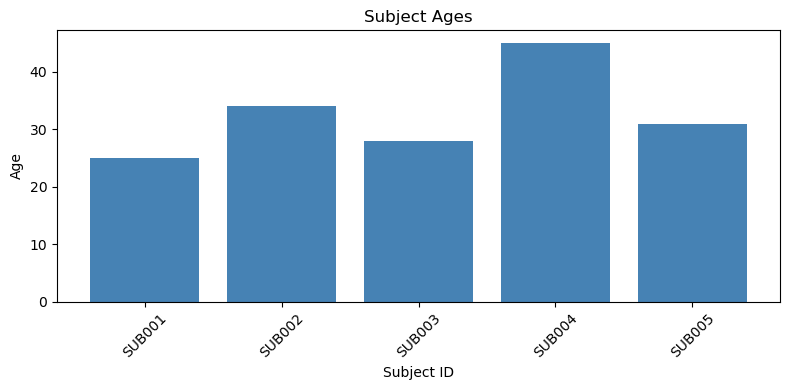

In [107]:
# Simple bar plot of ages
plt.figure(figsize=(8, 4))
plt.bar(df['subject_id'], df['age'], color='steelblue')
plt.xlabel('Subject ID')
plt.ylabel('Age')
plt.title('Subject Ages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

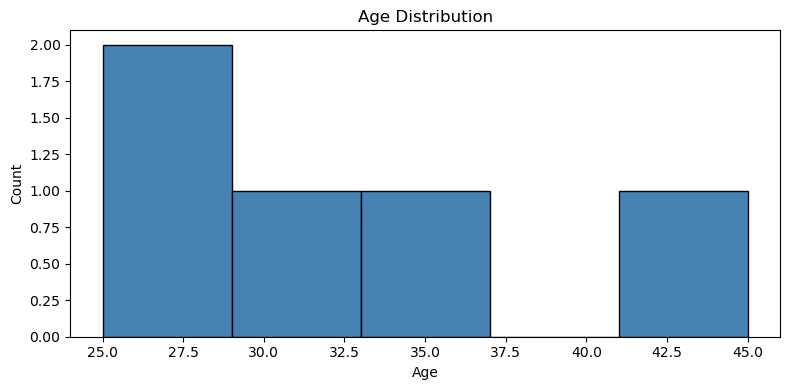

In [108]:
# Histogram of age distribution
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=5, color='steelblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

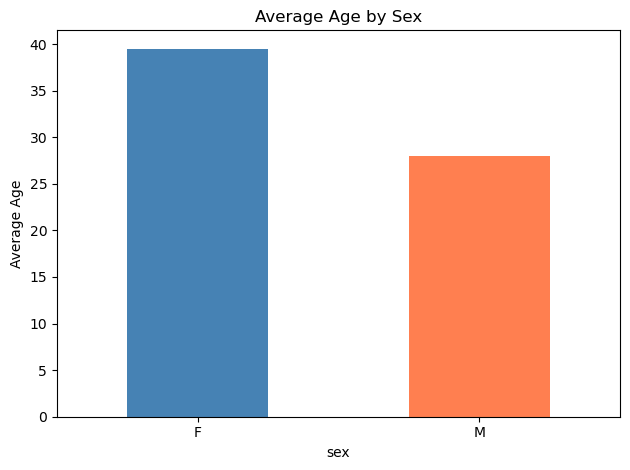

In [109]:
# Pandas built-in plotting
df.groupby('sex')['age'].mean().plot(kind='bar', color=['steelblue', 'coral'])
plt.ylabel('Average Age')
plt.title('Average Age by Sex')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

**End of Section 1**

You now have a foundation in:
- Shell/terminal commands for navigation and file operations
- Jupyter notebook features and magic commands
- Python standard library tools for file system operations
- Basic data manipulation with pandas and visualization with matplotlib

Continue to **Section 2: Finding & Exploring Mounted Data** to learn how to locate and work with data in the XNAT environment.

**Section 2** focuses on using the tools above to interact and utilize data on XNAT. 


---
## 2. Finding & Exploring Mounted Data

This section covers how to locate, navigate, and load data that is mounted within the XNAT notebook environment.

### Configuration

**Important:** The cell below defines the root data directory path. Modify this variable if your data is mounted at a different location.

---
### 2.1 Locating the /data Directory

The data directory is where XNAT mounts project data for notebook access. Let's use the tools from Section 1 to find and verify this location.

#### Using Shell Commands to Find the Data Directory

In [121]:
# XNAT's Notebook Environments will always mount your projects data at the root level
# Since we know where the data directory is, we can check for it using ls
!ls /  # This is a quick way to check, but might pull too much information
print("------------ Command Separation-----------")
!ls -l / | grep "data"  # Here we can use grep to pull only the dir we are interested in


bin   data  etc   lib	 lib64	 media	opt   root  sbin  sys  usr  workspace
boot  dev   home  lib32  libx32  mnt	proc  run   srv   tmp  var
------------ Command Separation-----------
drwxr-xr-x.   3 root root  22 Jan 13 16:54 data


In [124]:
# Another way is to use the 'find' command, but limit the depth of our search
# Try changing the max depth to see how it impacts the output!
!find / -maxdepth 1 -type d -name "data" 2>/dev/null

/data


In [130]:
# One big benefit of using Notebooks in XNAT is that your environemtn comes preconfigured for easy use!
# Instead of finding the data ourselves, we can simply find it using an env var!
finding_path_var = !printenv | grep -i "xnat_data"

print(f"Data path saved in env var: {finding_path_var}")

Data path saved in env var: ['XNAT_DATA=/data']


#### Using Python to Verify the Data Directory

In [131]:
# Now that we know where our data is mounted, let's assign it to a variable to be used by python
import os

DATA_DIR = os.getenv("XNAT_DATA")
print(f"This is our data dir: {DATA_DIR}")

This is our data dir: /data


In [132]:
# Check if the data directory exists
if os.path.exists(DATA_DIR):
    print(f"Data directory found: {DATA_DIR}")
    print(f"Is a directory: {os.path.isdir(DATA_DIR)}")
else:
    print(f"Data directory NOT found at: {DATA_DIR}")
    print("Please update the DATA_DIR variable in the configuration cell above.")

Data directory found: /data
Is a directory: True


##### Using `pathlib` library

`pathlib` is similar to `os` but allows for more convenient ways to interact w/ file path objects

In [135]:
from pathlib import Path

# Using pathlib to work with the data directory
data_path = Path(DATA_DIR)  # Here, we are just assigning our DATA_DIR to a path object

# Path objects have handy methods that let us check our filepaths quickly!
print(f"Data path: {data_path}")
print(f"Checking the path exists: {data_path.exists()}")
print(f"Checking the path is a directory: {data_path.is_dir()}")
print(f"Absolute path: {data_path.absolute()}")

Data path: /data
Checking the path exists: True
Checking the path is a directory: True
Absolute path: /data


---
### 2.2 Exploring the Data Directory Structure

Once you've located the data directory, let's explore its contents and understand the typical XNAT data hierarchy.

#### Listing Directory Contents

In [ ]:
# List top-level contents using shell command
!ls -la {DATA_DIR}

In [ ]:
# List contents using os.listdir()
print(f"Contents of {DATA_DIR}:")
try:
    for item in os.listdir(DATA_DIR):
        item_path = os.path.join(DATA_DIR, item)
        item_type = "dir" if os.path.isdir(item_path) else "file"
        print(f"  [{item_type}] {item}")
except FileNotFoundError:
    print(f"Directory not found: {DATA_DIR}")

In [ ]:
# Using pathlib for cleaner directory listing
data_path = Path(DATA_DIR)

if data_path.exists():
    print(f"Contents of {data_path}:\n")
    for item in sorted(data_path.iterdir()):
        item_type = "DIR " if item.is_dir() else "FILE"
        print(f"  [{item_type}] {item.name}")
else:
    print(f"Directory not found: {data_path}")

#### Understanding XNAT Data Hierarchy

XNAT typically organizes data in a hierarchical structure:
```
/data
├── projects/
│   └── <project_id>/
│       └── subjects/
│           └── <subject_id>/
│               └── experiments/
│                   └── <experiment_id>/
│                       └── scans/
│                           └── <scan_id>/
│                               └── resources/
```

The exact structure may vary based on your XNAT configuration.

In [ ]:
# Explore the directory tree (limit depth to avoid too much output)
!find {DATA_DIR} -maxdepth 3 -type d 2>/dev/null | head -30

#### Using Glob Patterns to Discover Files

In [ ]:
import glob

# Find all CSV files in the data directory
csv_files = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files[:10]:  # Show first 10
    print(f"  {f}")

In [ ]:
# Find all JSON files
json_files = glob.glob(f"{DATA_DIR}/**/*.json", recursive=True)
print(f"Found {len(json_files)} JSON files:")
for f in json_files[:10]:  # Show first 10
    print(f"  {f}")

In [ ]:
# Find common neuroimaging file types (NIfTI, DICOM)
nifti_files = glob.glob(f"{DATA_DIR}/**/*.nii", recursive=True)
nifti_gz_files = glob.glob(f"{DATA_DIR}/**/*.nii.gz", recursive=True)
dcm_files = glob.glob(f"{DATA_DIR}/**/*.dcm", recursive=True)

print(f"Found {len(nifti_files)} NIfTI files (.nii)")
print(f"Found {len(nifti_gz_files)} compressed NIfTI files (.nii.gz)")
print(f"Found {len(dcm_files)} DICOM files (.dcm)")

#### Inspecting File Types and Sizes

In [ ]:
# Function to get human-readable file size
def get_file_size(filepath):
    """Return file size in human-readable format."""
    size = os.path.getsize(filepath)
    for unit in ['B', 'KB', 'MB', 'GB']:
        if size < 1024:
            return f"{size:.1f} {unit}"
        size /= 1024
    return f"{size:.1f} TB"

# Example: Inspect CSV files if any exist
if csv_files:
    print("CSV files with sizes:")
    for f in csv_files[:5]:
        print(f"  {get_file_size(f):>10} - {f}")
else:
    print("No CSV files found to inspect")

In [ ]:
# Get a summary of all file types in the data directory
from collections import Counter

all_files = glob.glob(f"{DATA_DIR}/**/*", recursive=True)
files_only = [f for f in all_files if os.path.isfile(f)]

# Count file extensions
extensions = Counter()
for f in files_only:
    ext = Path(f).suffix.lower()
    if ext:
        extensions[ext] += 1
    else:
        extensions['(no extension)'] += 1

print(f"Total files found: {len(files_only)}\n")
print("File types summary:")
for ext, count in extensions.most_common(15):
    print(f"  {ext:>15}: {count}")

---
### 2.3 Loading Data into Pandas

Now that we can find our data files, let's load them into pandas DataFrames for analysis.

In [ ]:
import pandas as pd

#### Reading CSV/TSV Files

In [ ]:
# Find and load the first CSV file (if any exist)
csv_files = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)

if csv_files:
    # Load the first CSV file found
    sample_csv = csv_files[0]
    print(f"Loading: {sample_csv}\n")
    
    df = pd.read_csv(sample_csv)
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    display(df.head())
else:
    print("No CSV files found in the data directory.")
    print("Creating a sample DataFrame for demonstration...")
    
    # Create sample data for demonstration
    df = pd.DataFrame({
        'subject_id': ['SUB001', 'SUB002', 'SUB003'],
        'age': [25, 34, 28],
        'sex': ['M', 'F', 'M']
    })
    display(df)

In [ ]:
# Reading TSV (tab-separated) files
tsv_files = glob.glob(f"{DATA_DIR}/**/*.tsv", recursive=True)

if tsv_files:
    sample_tsv = tsv_files[0]
    print(f"Loading TSV: {sample_tsv}\n")
    
    df_tsv = pd.read_csv(sample_tsv, sep='\t')
    print(f"Shape: {df_tsv.shape[0]} rows x {df_tsv.shape[1]} columns")
    display(df_tsv.head())
else:
    print("No TSV files found.")
    print("To load a TSV file, use: pd.read_csv('file.tsv', sep='\\t')")

#### Loading JSON Data

In [ ]:
import json

# Find and load a JSON file
json_files = glob.glob(f"{DATA_DIR}/**/*.json", recursive=True)

if json_files:
    sample_json = json_files[0]
    print(f"Loading JSON: {sample_json}\n")
    
    # First, let's peek at the raw JSON structure
    with open(sample_json, 'r') as f:
        data = json.load(f)
    
    # Show the structure
    print(f"Type: {type(data)}")
    if isinstance(data, dict):
        print(f"Keys: {list(data.keys())[:10]}")  # Show first 10 keys
    elif isinstance(data, list):
        print(f"List length: {len(data)}")
else:
    print("No JSON files found in the data directory.")

In [ ]:
# Converting JSON to DataFrame (if structure is appropriate)
if json_files:
    try:
        # pd.read_json works well with JSON arrays or simple objects
        df_json = pd.read_json(sample_json)
        print("Successfully loaded JSON as DataFrame:")
        display(df_json.head())
    except ValueError as e:
        print(f"Could not directly convert to DataFrame: {e}")
        print("You may need to normalize nested JSON using pd.json_normalize()")
else:
    print("Example: df = pd.read_json('data.json')")
    print("For nested JSON: df = pd.json_normalize(json_data)")

#### Basic DataFrame Inspection

In [ ]:
# Using the DataFrame 'df' from earlier (or create sample data)
if 'df' not in dir() or df is None:
    df = pd.DataFrame({
        'subject_id': ['SUB001', 'SUB002', 'SUB003', 'SUB004', 'SUB005'],
        'age': [25, 34, 28, 45, 31],
        'sex': ['M', 'F', 'M', 'F', 'M'],
        'score': [85.5, 92.3, 78.1, 88.9, 91.2]
    })

# View first few rows
print("First 5 rows (head):")
display(df.head())

In [ ]:
# View last few rows
print("Last 5 rows (tail):")
display(df.tail())

In [ ]:
# Get DataFrame info (columns, types, non-null counts)
print("DataFrame Info:")
df.info()

In [ ]:
# Statistical summary of numeric columns
print("Statistical Summary:")
df.describe()

In [ ]:
# Column names and data types
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

#### Handling Common Data Loading Issues

In [ ]:
# Common read_csv options for handling different file formats

# Specify encoding for special characters
# df = pd.read_csv('file.csv', encoding='utf-8')
# df = pd.read_csv('file.csv', encoding='latin-1')

# Handle different delimiters
# df = pd.read_csv('file.csv', sep=',')      # Comma (default)
# df = pd.read_csv('file.tsv', sep='\t')     # Tab
# df = pd.read_csv('file.txt', sep='|')      # Pipe

# Skip header rows
# df = pd.read_csv('file.csv', skiprows=2)

# Specify which columns to load
# df = pd.read_csv('file.csv', usecols=['col1', 'col2'])

# Handle missing values
# df = pd.read_csv('file.csv', na_values=['NA', 'N/A', 'missing'])

print("Common pd.read_csv() parameters:")
print("  encoding='utf-8'    - Specify character encoding")
print("  sep='\\t'            - Use tab as delimiter")
print("  skiprows=N          - Skip first N rows")
print("  usecols=[...]       - Load only specific columns")
print("  na_values=[...]     - Additional values to treat as NaN")

In [ ]:
# Helper function to load data files from the data directory
def load_data_file(filename, file_type='csv', **kwargs):
    """
    Search for and load a data file from the DATA_DIR.
    
    Parameters:
        filename: Name or pattern to search for
        file_type: 'csv', 'tsv', or 'json'
        **kwargs: Additional arguments passed to pandas read function
    
    Returns:
        DataFrame or None if file not found
    """
    # Search for the file
    pattern = f"{DATA_DIR}/**/*{filename}*"
    matches = glob.glob(pattern, recursive=True)
    
    if not matches:
        print(f"No files matching '{filename}' found in {DATA_DIR}")
        return None
    
    filepath = matches[0]
    print(f"Loading: {filepath}")
    
    if file_type == 'csv':
        return pd.read_csv(filepath, **kwargs)
    elif file_type == 'tsv':
        return pd.read_csv(filepath, sep='\t', **kwargs)
    elif file_type == 'json':
        return pd.read_json(filepath, **kwargs)
    else:
        print(f"Unknown file type: {file_type}")
        return None

# Example usage:
# df = load_data_file('subjects', file_type='csv')
# df = load_data_file('demographics.tsv', file_type='tsv')

---

**End of Section 2**

You now know how to:
- Locate the mounted data directory using shell commands and Python
- Explore the data directory structure and understand XNAT hierarchy
- Use glob patterns to discover files of different types
- Load CSV, TSV, and JSON files into pandas DataFrames
- Inspect DataFrames using `head()`, `tail()`, `info()`, and `describe()`
- Handle common data loading issues

Continue to **Section 3: Using XNATpy SDK** to learn how to programmatically access XNAT resources.

---
## 3. Using XNATpy SDK

This section covers programmatic access to XNAT using the XNATpy Python library.

### 3.1 Installation & Setup
*Coming soon...*

### 3.2 Authenticating with XNAT
*Coming soon...*

### 3.3 Finding Projects & Data
*Coming soon...*

### 3.4 Working with Mounted Data via XNATpy
*Coming soon...*